### 第3章 图像运算
#### 3.1 加法运算
- `(a + b) = mod(a + b, 256)`: 取模运算
- `cv2.add()`: 饱和值求和

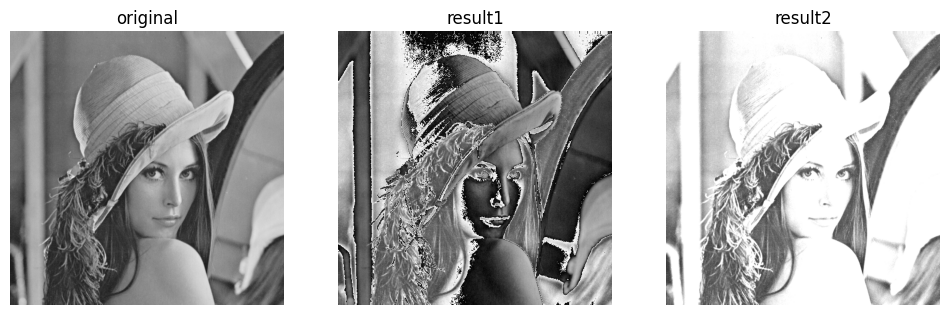

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
a = cv2.imread("lena.bmp", 0)
b = a
result1 = a + b
result2 = cv2.add(a, b)

# 直接使用OpenCV显示图像
# cv2.imshow("original", a)
# cv2.imshow("result1", result1)
# cv2.imshow("result2", result2)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
result1 = cv2.cvtColor(result1, cv2.COLOR_BGR2RGB)
result2 = cv2.cvtColor(result2, cv2.COLOR_BGR2RGB)

# 使用Matplotlib显示图像
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(a)
plt.title("original")
plt.axis("off")

plt.subplot(132)
plt.imshow(result1)
plt.title("result1")
plt.axis("off")

plt.subplot(133)
plt.imshow(result2)
plt.title("result2")
plt.axis("off")

plt.show()

#### 3.2 图像加权和
`dst = saturate(src1 * α + src2 * β + Γ`

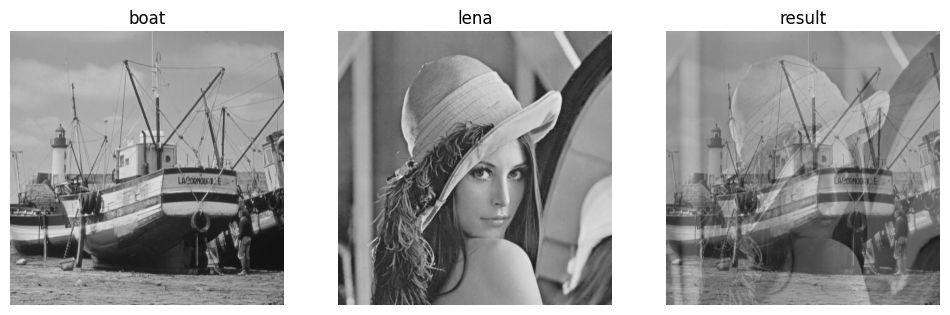

In [43]:
import cv2
a = cv2.imread("boat.bmp")
b = cv2.imread("lena.bmp")
result = cv2.addWeighted(a, 0.6, b, 0.4, 0)

a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
b = cv2.cvtColor(b, cv2.COLOR_BGR2RGB)
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(a)
plt.title("boat")
plt.axis("off")

plt.subplot(132)
plt.imshow(b)
plt.title("lena")
plt.axis("off")

plt.subplot(133)
plt.imshow(result)
plt.title("result")
plt.axis("off")
plt.show()


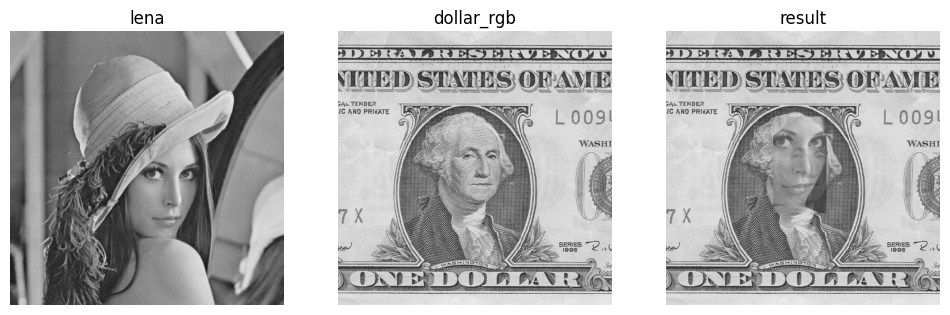

In [ ]:
import cv2
lena = cv2.imread("lena512.bmp", cv2.IMREAD_UNCHANGED)
dollar = cv2.imread("dollar.bmp", cv2.IMREAD_UNCHANGED)
dollar_rgb = cv2.cvtColor(dollar, cv2.COLOR_BGR2RGB)

face1 = lena[220:400, 250:350]
face2 = dollar[160:340, 200:300]
add = cv2.addWeighted(face1, 0.7, face2, 0.3, 0)
dollar[160:340, 200:300] = add

lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
result = cv2.cvtColor(dollar, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(lena)
plt.title("lena")
plt.axis("off")

plt.subplot(132)
plt.imshow(dollar_rgb)
plt.title("dollar")
plt.axis("off")

plt.subplot(133)
plt.imshow(result)
plt.title("result")
plt.axis("off")
plt.show()

#### 3.3 按位逻辑运算
- `cv2.bitwese_and()` 按位与
- `cv2.bitwese_or()` 按位或
- `cv2.bitwese_xor()` 按位异或
- `cv2.bitwese_not()` 按位取反

#### 3.4 掩膜
- OpenCV 中使用掩膜参数时，操作只会在掩膜值非空的像素点上执行，并将其他像素点置为0

a.shape= (512, 512, 3)
mask.shape= (512, 512)


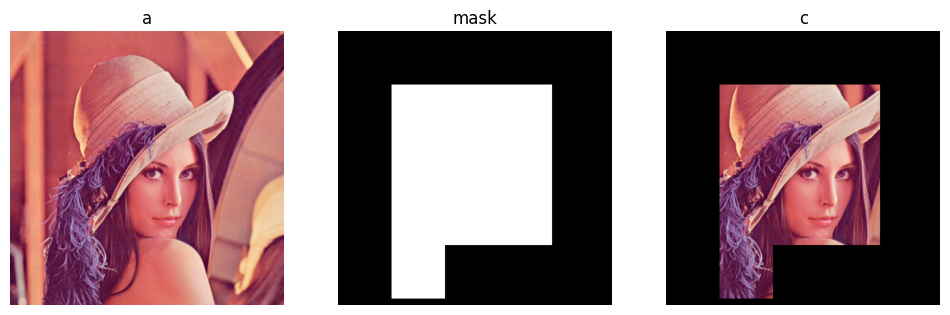

In [48]:
import cv2
import numpy  as np
a = cv2.imread("lenacolor.png",1)
h, w, c = a.shape
m = np.zeros((h, w),dtype=np.uint8)
m[100:400, 200:400] = 255   # 等于1也可以，但是掩膜图像是全黑的图像，显示时无法看到
m[100:500, 100:200] = 255
c = cv2.bitwise_and(a, a, mask=m)
print("a.shape=", a.shape)
print("mask.shape=", m.shape)

a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
m = cv2.cvtColor(m, cv2.COLOR_BGR2RGB)
c = cv2.cvtColor(c, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(a)
plt.title("a")
plt.axis("off")

plt.subplot(132)
plt.imshow(m)
plt.title("mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(c)
plt.title("c")
plt.axis("off")
plt.show()

#### 3.5 位平面分解
- 将灰度图像中所有像素点处于同一比特位的二进制值提取出来，得到一幅二值图像，该图像称为灰度图像的一个位平面，这个过程称为位平面分解

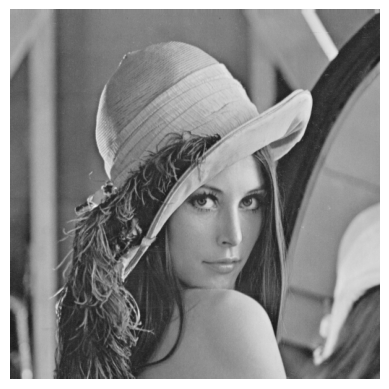

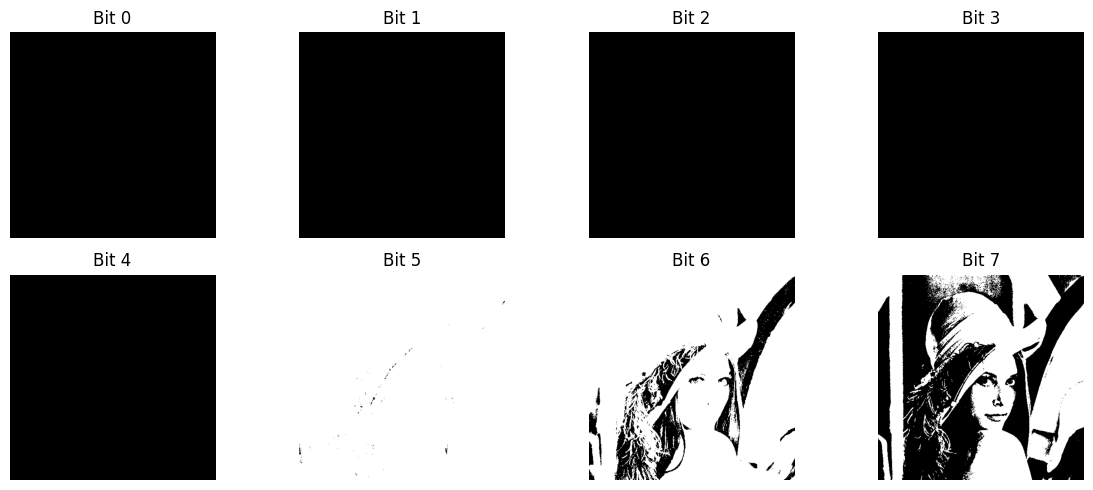

In [19]:
import cv2
import numpy as np
lena = cv2.imread("lena.bmp", 0)
lena_rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
plt.imshow(lena_rgb)
plt.axis('off')

r, c = lena.shape
x = np.zeros((r, c, 8),dtype=np.uint8)  # x是用于提取各个位平面的提取矩阵
for i in range(8):
    x[:, :, i] = 1 << i   # 提取各个位平面的值: 1, 2, 4, 8, 16, 32, 64, 128
ri = np.zeros((r, c, 8),dtype=np.uint8)
for i in range(8):
    ri[:, :, i] = cv2.bitwise_and(lena, x[:, :, i])
    mask = ri[:, :, i] > 0
    ri[mask] = 255  # 让二值平面以黑白显示，大于零的值设为255

# ===================== 用 matplotlib 显示 8 张图 =====================

plt.figure(figsize=(12, 5))  # 设置画布大小
for i in range(8):
    plt.subplot(2, 4, i+1)  # 2行4列排列
    plt.imshow(ri[:, :, i], cmap="gray")  # 灰度显示
    plt.title(f"Bit {i}")
    plt.axis('off')

plt.tight_layout()  # 自动调整间距
plt.show()


#### 3.6 图像的加密和解密
- 通过对原始图像与密钥图像进行按位异或实现加密
- 将加密后的图像与密钥图像再次进行按位异或实现解密

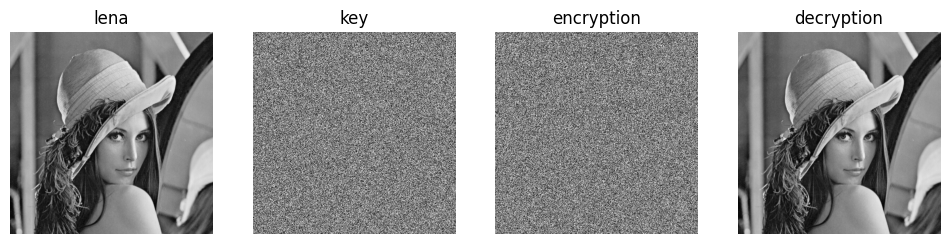

In [ ]:
import cv2
import numpy as np
lena = cv2.imread("lena.bmp", 0)    # 明文(原始)图像
r, c = lena.shape
key = np.random.randint(0, 256, size=[r, c], dtype=np.uint8)    # 密钥图像
encryption = cv2.bitwise_xor(lena, key)     # 加密图像 
decryption = cv2.bitwise_xor(encryption, key)   # 解密图像

plt.figure(figsize=(12, 5))  # 设置画布大小
plt.subplot(141)
plt.imshow(lena, cmap="gray")
plt.title("lena")
plt.axis("off")

plt.subplot(142)
plt.imshow(key, cmap="gray")
plt.title("key")
plt.axis("off")

plt.subplot(143)
plt.imshow(encryption, cmap="gray")
plt.title("encryption")
plt.axis("off")

plt.subplot(144)
plt.imshow(decryption, cmap="gray")
plt.title("decryption")
plt.axis("off")
plt.show()


#### 3.7 数字水印
- 将一个需要隐藏的二值图像信息嵌入载体图像(能够隐藏其他图像的图像)的最低有效位，即将载体图像的最低有效位替换为当前需要隐藏的二值图像，从而实现将二值图像隐藏的目的。
- 由于二值图像位于载体图像的最低有效位上，对载体图像影响非常小，具有较高的隐蔽性。

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


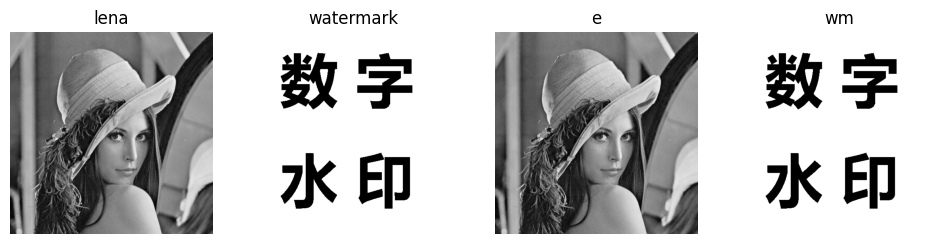

In [ ]:
import cv2
import numpy as np
# 读取原始载体图像
lena = cv2.imread("lena.bmp", 0)    # 原始图像
# 读取水印图像
watermark = cv2.imread("watermark.bmp", 0)  # 二值水印图像
# 将水印内的255处理为1，以方便嵌入。
w = watermark[:, :] > 0
watermark[w] = 1
# 读取原始载体图像的shape值
r, c = lena.shape
# ============嵌入过程============ #
# 生成内部值都是254的数组
t254 = np.ones((r, c), dtype=np.uint8) * 254
# 获取lena图像的高7位
lenaH7 = cv2.bitwise_and(lena, t254)
# 将watermark嵌入到lenaH7内，即lenaH7的最低位被watermark替换
e = cv2.bitwise_or(lenaH7, watermark)   # 含水印的载体图像
## 8位二进制灰度图像，高7位是原始图像的高7位，最低位是水印图像的值（0或1）
#============提取过程============
# 生成内部值都是1的数组
t1 = np.ones((r, c), dtype=np.uint8)
# 从载体图像内，提取水印图像
wm = cv2.bitwise_and(e, t1)
print(wm)
# 将水印内的1处理为255以方便显示
w = wm[:, :] > 0
wm[w] = 255
print(wm)
#============显示============
plt.figure(figsize=(12, 5))  # 设置画布大小
plt.subplot(141)
plt.imshow(lena, cmap="gray")
plt.title("lena")
plt.axis("off")

plt.subplot(142)
plt.imshow(watermark*255, cmap="gray")  # matplotlib 会自动拉伸对比度，但cv2.imshow显示时必须乘以255
plt.title("watermark")
plt.axis("off")

plt.subplot(143)
plt.imshow(e, cmap="gray")
plt.title("e")
plt.axis("off")

plt.subplot(144)
plt.imshow(wm, cmap="gray")
plt.title("wm")
plt.axis("off")
plt.show()

#### 3.8 脸部打码和解码
- ROI 方式

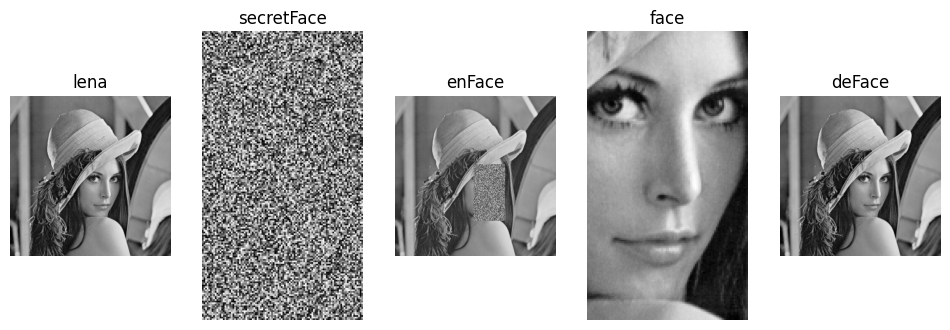

In [ ]:
import cv2
import numpy as np
# 读取原始载体图像
lena =  cv2.imread("lena.bmp",0)
# 读取原始载体图像的shape值
r, c = lena.shape
# 设置ROI区域
roi = lena[220:400, 250:350]
# 获取一个key,打码、解码所使用的密钥
key = np.random.randint(0, 256, size=[r, c], dtype=np.uint8)
# ============脸部打码过程============ #
# 复制一份lena，用于加密. encrypt 取前两个字符用于表示加密
enFace = lena.copy()    
# 使用密钥key加密原始图像lena（按位异或）
lenaXorKey = cv2.bitwise_xor(enFace, key) 
# 获取加密后图像的脸部区域（获取ROI）
secretFace = lenaXorKey[220:400, 250:350]
# 将lena的脸部区域，替换为加密后的脸部区域secretFace（ROI替换）
enFace[220:400, 250:350] = secretFace
# lena[220:400,250:350]，即为获取lena的ROI区域（获取ROI）
#============脸部解码过程============ #
# 复制一份加密后的lena(enFace)得到deFace，decrypt 方便后续解码、演示. 
deFace = enFace.copy()
# 将脸部打码的lena与密钥key异或，得到脸部的原始信息（按位异或）
extractOriginal = cv2.bitwise_xor(deFace, key)
# 获取解密后图像的脸部区域（获取ROI）
face = extractOriginal[220:400, 250:350]
# 将maskFace的脸部区域，替换为解密的脸部区域face（ROI替换）
deFace[220:400, 250:350] = face
# ============显示图像============ #
plt.figure(figsize=(12, 5))  # 设置画布大小
plt.subplot(151)
plt.imshow(lena, cmap="gray")
plt.title("lena")
plt.axis("off")

plt.subplot(152)
plt.imshow(secretFace, cmap="gray")
plt.title("secretFace")
plt.axis("off")

plt.subplot(153)
plt.imshow(enFace, cmap="gray")
plt.title("enFace")
plt.axis("off")

plt.subplot(154)
plt.imshow(face, cmap="gray")
plt.title("face")
plt.axis("off")

plt.subplot(155)
plt.imshow(deFace, cmap="gray")
plt.title("deFace")
plt.axis("off")
plt.show()